In [1]:
%load_ext autoreload
%autoreload 2

import torch
import torch.nn as nn
import torch.optim as optim
from torch.autograd import Variable
import torch.nn.functional as F 
from collections import OrderedDict
from dataLoaders import load_train_val, load_test
from CustomNeuralNetwork import customNet


In [2]:

x_train, x_val, y_train, y_val = load_train_val(pytorch=True)

# print(x_train[0])    
print(f"number of training samples: {len(x_train)}")    
print(f"Input Images size: {x_train[0].shape}")

number of training samples: 10200
Input Images size: torch.Size([784])


In [3]:
INPUT_DATA_SIZE = 784
NUM_CLASSES = 10
LEARNING_RATE = 0.03


myNet = customNet(INPUT_DATA_SIZE, NUM_CLASSES, LEARNING_RATE)


In [4]:
myNet.initializeWeights()


In [5]:
myNet.emptyLossLists()

In [6]:
batch_size = 64
epochs = 30

myNet.train(x_train, y_train, x_val, y_val, batch_size=batch_size, epochs=epochs)


Epoch 1, Total Loss: 142.77311596274376,  Total Evaluation Loss: 140.78523716330528
Epoch 2, Total Loss: 66.79024547338486,  Total Evaluation Loss: 67.2065149396658
Epoch 3, Total Loss: 53.711713925004005,  Total Evaluation Loss: 55.58009433746338
Epoch 4, Total Loss: 46.69783280044794,  Total Evaluation Loss: 49.86280716955662
Epoch 5, Total Loss: 41.7895832657814,  Total Evaluation Loss: 46.1056482642889
Epoch 6, Total Loss: 37.955538764595985,  Total Evaluation Loss: 43.308051481842995
Epoch 7, Total Loss: 34.76410194858909,  Total Evaluation Loss: 41.086189955472946
Epoch 8, Total Loss: 32.028705168515444,  Total Evaluation Loss: 39.24546713382006
Epoch 9, Total Loss: 29.604308299720287,  Total Evaluation Loss: 37.68080620467663
Epoch 10, Total Loss: 27.422465175390244,  Total Evaluation Loss: 36.31262233108282
Epoch 11, Total Loss: 25.439420271664858,  Total Evaluation Loss: 35.09806374460459
Epoch 12, Total Loss: 23.62643814831972,  Total Evaluation Loss: 34.01901611685753
Epoch 

In [7]:

trainingLoss = myNet.getTrainingLoss()
validationLoss = myNet.getValidationLoss()
epochs = list(range(1, len(trainingLoss)+1))

print(validationLoss)


[140.78523716330528, 67.2065149396658, 55.58009433746338, 49.86280716955662, 46.1056482642889, 43.308051481842995, 41.086189955472946, 39.24546713382006, 37.68080620467663, 36.31262233108282, 35.09806374460459, 34.01901611685753, 33.07350239530206, 32.22231723368168, 31.455824188888073, 30.774579867720604, 30.161443792283535, 29.605539087206125, 29.115620348602533, 28.67787578701973, 28.294989500194788, 27.94794050976634, 27.642267905175686, 27.380685210227966, 27.141328006982803, 26.944808393716812, 26.762950088828802, 26.610322758555412, 26.47716600820422, 26.35402938351035]


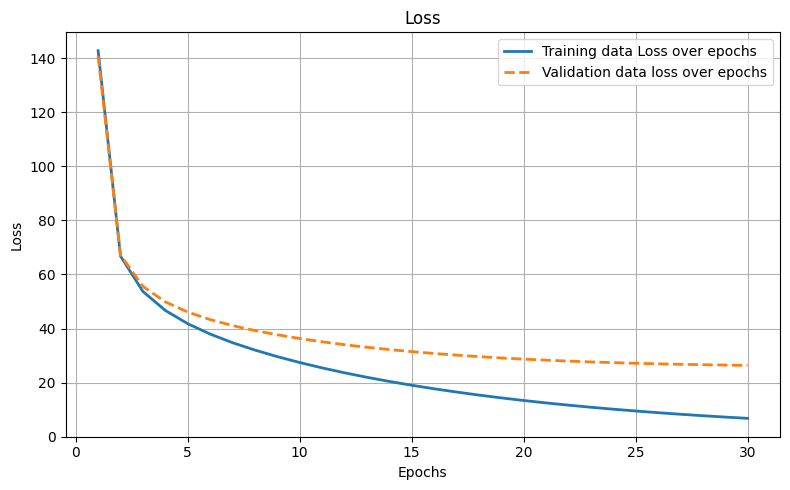

In [8]:

from helperPlots import plot_two_curves

plot_two_curves(epochs, trainingLoss, validationLoss, "Training data Loss over epochs", "Validation data loss over epochs", "Loss", "Epochs", "Loss")